# Stage 7: 1D Convolutional Network over MFCC Sequences

Stage 6 established that adding mel-frequency cepstral coefficients (MFCCs) to the feature vector substantially improves classification accuracy, but summarized each utterance's MFCCs to a mean and standard deviation per coefficient, discarding the temporal order in which sounds occurred. This stage addresses that limitation directly: rather than summarizing, the full per-frame MFCC sequence is retained (padded or truncated to a fixed length), and a one-dimensional convolutional neural network (1D-CNN) is trained from scratch to classify intents directly from this sequence. Unlike the classifiers in Stages 5-6, this model is not restricted to hand-aggregated summary statistics and can in principle learn temporal patterns spanning multiple frames.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

DATA_ROOT = "../data/fluent_speech_commands_dataset"
data = np.load(f"{DATA_ROOT}/mfcc_sequences.npz", allow_pickle=True)
X, split, intent = data["X"], data["split"], data["intent"]
print(f"X shape: {X.shape} (utterances, time steps, MFCC coefficients)")
print(f"Splits: {pd.Series(split).value_counts().to_dict()}")

X shape: (30043, 350, 13) (utterances, time steps, MFCC coefficients)
Splits: {'train': 23132, 'test': 3793, 'valid': 3118}


## Data preparation

Each utterance's MFCC sequence was extracted with the same 25 ms frame length, 10 ms hop, and 13 coefficients used in Stage 6 (`scripts/extract_mfcc_sequences.py`), then padded or truncated to a fixed 350 time steps, covering approximately the 95th percentile of utterance lengths in the corpus. Features are standardized per coefficient using training-set statistics only. Intent labels are integer-encoded for use with a sparse categorical cross-entropy loss.

In [2]:
train_mask, valid_mask, test_mask = split == "train", split == "valid", split == "test"

mean = X[train_mask].mean(axis=(0, 1), keepdims=True)
std = X[train_mask].std(axis=(0, 1), keepdims=True) + 1e-8
X_norm = (X - mean) / std

label_encoder = LabelEncoder().fit(intent)
y = label_encoder.transform(intent)
n_classes = len(label_encoder.classes_)

X_train, y_train = X_norm[train_mask], y[train_mask]
X_valid, y_valid = X_norm[valid_mask], y[valid_mask]
X_test, y_test = X_norm[test_mask], y[test_mask]

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}, classes: {n_classes}")

Train: (23132, 350, 13), Valid: (3118, 350, 13), Test: (3793, 350, 13), classes: 31


## Model architecture

The network consists of three 1D convolutional blocks (convolution, batch normalization, and, for the first two blocks, max pooling to progressively reduce the time dimension), followed by global average pooling across time, a dense hidden layer with dropout for regularization, and a softmax output layer. Convolutional filters slide along the time axis, so early layers can learn short, local temporal patterns (analogous to phoneme-scale transitions) while later layers, operating on a downsampled and pooled representation, have access to a wider effective temporal context. This is a modest architecture trained entirely from scratch on this corpus; no pretrained weights are used.

In [3]:
tf.random.set_seed(0)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Conv1D(64, 5, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(128, 5, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(n_classes, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 350, 64)        │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 175, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 175, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 87, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 87, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,871 (452.62 KB)

 Trainable params: 115,487 (451.12 KB)

 Non-trainable params: 384 (1.50 KB)

## Training

The model is trained with early stopping on validation accuracy (patience of 8 epochs, restoring the best-observed weights), for up to 50 epochs, to avoid manually selecting a fixed epoch count.

In [4]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=128, epochs=50,
    callbacks=[early_stop], verbose=2,
)

Epoch 1/50


181/181 - 9s - 49ms/step - accuracy: 0.1814 - loss: 2.7428 - val_accuracy: 0.1921 - val_loss: 2.6481


Epoch 2/50


181/181 - 8s - 47ms/step - accuracy: 0.3297 - loss: 2.0189 - val_accuracy: 0.2909 - val_loss: 2.2866


Epoch 3/50


...

181/181 - 7s - 39ms/step - accuracy: 0.9693 - loss: 0.0932 - val_accuracy: 0.6533 - val_loss: 2.1587


Epoch 37/50


181/181 - 7s - 40ms/step - accuracy: 0.9726 - loss: 0.0827 - val_accuracy: 0.6517 - val_loss: 2.2231


Epoch 38/50


181/181 - 7s - 39ms/step - accuracy: 0.9735 - loss: 0.0812 - val_accuracy: 0.6668 - val_loss: 2.0094


## Training curves

Training and validation accuracy and loss are plotted below to check for overfitting and confirm early stopping behaved as intended.

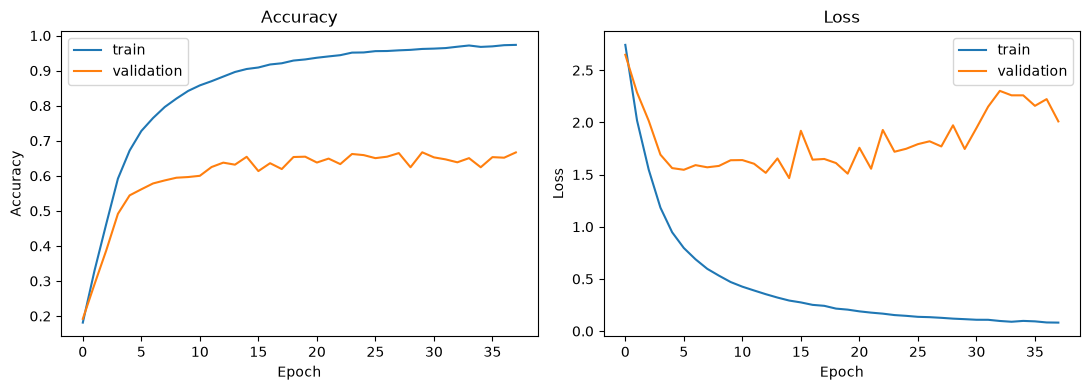

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()
axes[0].set_title("Accuracy")

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()
axes[1].set_title("Loss")
fig.tight_layout()
plt.show()

## Test evaluation and confusion matrix

Test accuracy: 0.8442


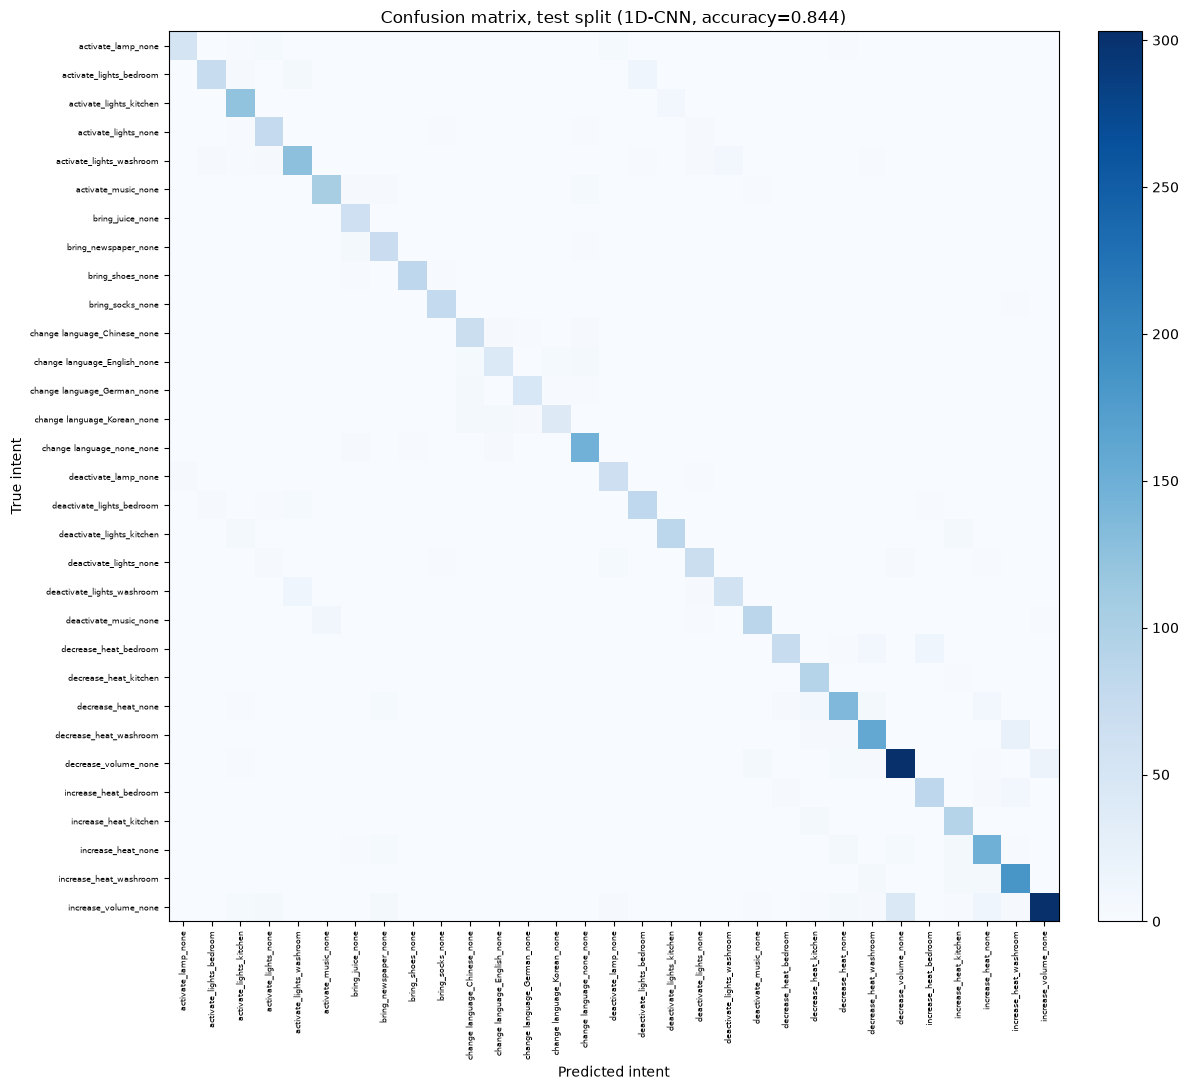

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
ax.set_xticklabels(label_encoder.classes_, rotation=90, fontsize=6)
ax.set_yticklabels(label_encoder.classes_, fontsize=6)
ax.set_xlabel("Predicted intent"); ax.set_ylabel("True intent")
ax.set_title(f"Confusion matrix, test split (1D-CNN, accuracy={test_acc:.3f})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Reliability of a single fixed split

The test accuracy above (0.844, far exceeding the validation accuracy observed during training, which plateaued around 0.62-0.67) is large enough to warrant scrutiny before being reported as a measure of the model's generalization. The FSC corpus's provided validation and test splits each contain only 10 speakers. With this few speakers per split, a per-speaker accuracy breakdown is used to check whether the discrepancy reflects genuine generalization or the particular, small set of speakers each split happens to contain.

In [7]:
base = pd.read_csv(f"{DATA_ROOT}/features_cache.csv")
speaker_map = dict(zip(base["path"], base["speakerId"]))
speaker = np.array([speaker_map[p] for p in data["path"]])
speaker_valid, speaker_test = speaker[valid_mask], speaker[test_mask]

val_pred = np.argmax(model.predict(X_valid, verbose=0), axis=1)

print("Per-speaker validation accuracy:")
for spk in sorted(set(speaker_valid)):
    m = speaker_valid == spk
    print(f"  {spk}: n={m.sum():4d} acc={(val_pred[m] == y_valid[m]).mean():.3f}")

print("\nPer-speaker test accuracy:")
for spk in sorted(set(speaker_test)):
    m = speaker_test == spk
    print(f"  {spk}: n={m.sum():4d} acc={(y_pred[m] == y_test[m]).mean():.3f}")

Per-speaker validation accuracy:
  7NqqnAOPVVSKnxyv: n= 491 acc=0.892
  8B9N9jOOXGUordVG: n= 426 acc=0.671
  9MX3AgZzVgCw4W4j: n=  83 acc=0.398
  D4jGxZ7KamfVo4E2V: n= 286 acc=0.916
  DWNjK4kYDACjeEg3: n= 197 acc=0.954
  NgXwdx5KkZI5GRWa: n= 491 acc=0.707
  Pz327QrLaGuxW8Do: n= 166 acc=0.349
  eBQAWmMg4gsLYLLa: n= 481 acc=0.241
  mj4BWeRbp7ildyB9d: n= 484 acc=0.705
  vnljypgejkINbBAY: n=  13 acc=0.846

Per-speaker test accuracy:
  4BrX8aDqK2cLZRYl: n= 481 acc=0.881
  7B4XmNppyrCK977p: n= 493 acc=0.925
  NgQEvO2x7Vh3xy2xz: n= 360 acc=0.856
  Q4vMvpXkXBsqryvZ: n= 181 acc=0.713
  V4ZbwLm9G5irobWn: n= 491 acc=0.953
  V4ejqNL4xbUKkYrV: n= 477 acc=0.692
  aokxBz9LxXHzZzay: n= 100 acc=0.850
  k5bqyxx2lzIbrlg9: n= 487 acc=0.737
  oOK5kxoW7dskMbaK: n= 428 acc=0.942
  ppymZZDb2Bf4NQnE: n= 295 acc=0.814


## Speaker-grouped cross-validation

The per-speaker breakdown shows the validation split's overall accuracy is disproportionately reduced by three speakers on whom the model performs poorly (accuracy of 0.398, 0.349, and 0.241), while every test-split speaker achieves at least 0.69. This is consistent with the discrepancy being substantially driven by which particular speakers each fixed split happens to contain, rather than by a systematic difference in the difficulty of validation versus test utterances. Given this, the fixed-split test accuracy is not treated as a reliable estimate of generalization on its own.

To obtain a more reliable estimate, 5-fold group cross-validation is performed over all 97 speakers in the corpus (`scripts/run_cnn_cross_validation.py`), using speaker identity as the grouping variable so that no speaker appears on both sides of any fold. Each fold's training speakers are further split 90/10 by speaker for early-stopping validation, and the same architecture and training procedure used above is applied to each fold. This is run as a standalone script rather than inside this notebook, since it retrains the model 5 times (approximately 20 minutes total); results are loaded here.

 fold  held_out_acc  n_train  n_val  n_held_out
    1      0.697686    22028   2008        6007
    2      0.653801    22117   1915        6011
    3      0.728907    21411   2623        6009
    4      0.766811    21311   2724        6008
    5      0.775632    22061   1974        6008

Mean held-out accuracy: 0.7246 +/- 0.0504


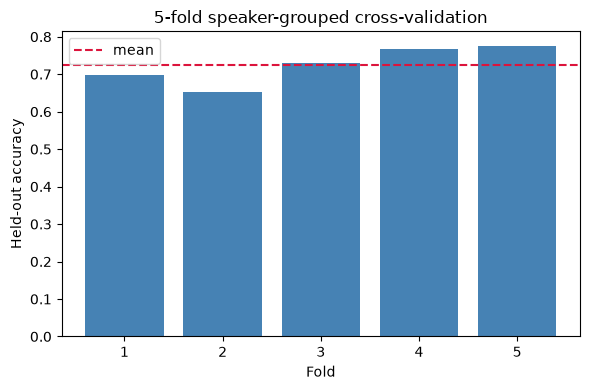

In [8]:
cv_results = pd.read_csv(f"{DATA_ROOT}/cnn_cv_results.csv")
print(cv_results.to_string(index=False))
print(f"\nMean held-out accuracy: {cv_results['held_out_acc'].mean():.4f} +/- {cv_results['held_out_acc'].std():.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cv_results["fold"], cv_results["held_out_acc"], color="steelblue")
ax.axhline(cv_results["held_out_acc"].mean(), color="crimson", linestyle="--", label="mean")
ax.set_xlabel("Fold"); ax.set_ylabel("Held-out accuracy")
ax.set_title("5-fold speaker-grouped cross-validation")
ax.set_xticks(cv_results["fold"])
ax.legend()
fig.tight_layout()
plt.show()

## Results

A single fixed-split evaluation of the 1D-CNN produced a test accuracy of 0.844, far exceeding the validation accuracy (0.62-0.67) observed throughout training. A per-speaker breakdown showed this discrepancy is attributable to the small number of speakers (10) in each of the corpus's provided validation and test splits: three validation speakers had markedly low accuracy (0.398, 0.349, and 0.241), pulling down the overall validation figure, while all ten test speakers achieved at least 0.692. With so few speakers per split, a single fixed-split accuracy figure is not a reliable estimate of generalization for this model.

Five-fold speaker-grouped cross-validation across all 97 corpus speakers gives a mean held-out accuracy of 0.725 (standard deviation 0.050, range 0.654-0.776 across folds). This is treated as the reliable headline result for this stage, in preference to any single split's figure. It represents a substantial improvement over both the Stage 5 prosodic-feature classifiers (16.5% test accuracy) and the Stage 6 MFCC-summary-statistic classifiers (25.8%), consistent with the hypothesis that retaining temporal order in the MFCC sequence, rather than only adding richer per-frame spectral content, provides considerable further benefit. The fold-to-fold standard deviation (5.0 percentage points) itself quantifies the same small-speaker-count sensitivity identified above and should be reported alongside the mean whenever this result is cited.

This result is obtained from a model trained entirely from scratch on this corpus, with no pretrained weights, and remains within the project's constraint that the core pipeline does not rely on an external pretrained model. Exact single-split figures in this notebook are not fully deterministic across re-executions (TensorFlow does not guarantee bitwise-identical results on CPU across runs even with a fixed random seed); the qualitative finding -- a small-speaker-count-driven split unreliability, resolved by cross-validation -- and the cross-validation figures themselves (computed once and cached) are the results that should be cited.